In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

# Radiation
## CERES

In [270]:
fp = '/data/jmex/CERES/CERES_TOA.nc'

#oceanic mean
ceres = xr.open_dataset(fp).where(ocean_mask)
weights = np.cos(np.deg2rad(ceres.lat))
ceres = ceres.weighted(weights).mean(['lat', 'lon'])

#rolling average 
ceres = ceres.rolling(time = 6, center = True, min_periods = 3).mean()
ceres = ceres.sel(time = slice('2000-06', '2024-01'))

In [271]:
#copy net toa only
r = ceres[['toa_net_all_mon']]
r = r.rename({'toa_net_all_mon':'toa'})

In [272]:
def detrend_monthly(da, var, time_selection = slice('2000', '2020')):

    # Function to compute trend for each month
    def compute_trend(da):
        time_numeric = np.arange(len(da.time))  # Convert time to numeric index
        slope, intercept, _, _, _ = linregress(time_numeric, da.values)  # Linear regression
        return slope  # Trend (change per time step)

    # Initialize lists to store trends
    trend_list = []

    # Loop through each month (1-12)
    for month in range(1, 13):
        da_subset = da.sel(time = time_selection)
        da_month = da_subset[var].sel(time=da_subset.time.dt.month == month)  # Select data for that month
        trend = compute_trend(da_month)  # Compute trend
        trend_list.append(trend)

    # Convert trends to xarray DataArray
    monthly_trends = xr.DataArray(trend_list, coords=[np.arange(1, 13)], dims=["month"], name="trend")

    # Add trend values to the original dataset
    da = da.assign(trend=monthly_trends)

    # Compute the detrended variable
    detrended_list = []

    for month in range(1, 13):
        da_month = da[var].sel(time=da.time.dt.month == month)  # Select data for that month
        trend_value = da['trend'].sel(month=month)  # Get trend for that month
        time_numeric = np.arange(len(da_month.time))  # Numeric time indices
        detrended_values = da_month - (trend_value.values * time_numeric)  # Subtract trend
        detrended_list.append(detrended_values)

    # Combine detrended data into a single DataArray
    detrended = xr.concat(detrended_list, dim="time")

    # Assign detrended variable to dataset
    da = da.assign(detrended=detrended)

    #drop the month
    da = da.drop_dims('month')

    #compute the anomaly
    clim = da.groupby('time.month').mean()
    da_anom = da.groupby('time.month') - clim
    return da_anom

In [273]:
r_anom = detrend_monthly(r, 'toa')

## ERA5

In [274]:
#all (Sw+lw) TOA; net and clear-sky. downward positive
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_n.nc'
n= xr.open_dataset(fp)
#change the longitude defintion to 0-360
n['longitude'] = (n['longitude']+360)%360
n = n.sortby('longitude')

#change the longitude defintion to 0-360
n = n.rename({'latitude':'lat', 'longitude':'lon'})
n = n.drop_vars(['number', 'expver'])

n = n.rename({'valid_time':'time'})

#rolling avereage
n = n.rolling(time = 6, center = True, min_periods =3).mean()

n = n.sel(time = slice('1979', '2024-03'))

#total short and longwave
n['n'] = n.tsr+n.ttr
n = n[['n']]

#over indo-pac only
n = n.where(ocean_mask)

#convert to w/m2
n = n/(60**2*24)

#oceanic mean
weights = np.cos(np.deg2rad(n.lat))
n = n.weighted(weights).mean(['lat', 'lon'])



In [275]:
n_anom = detrend_monthly(n, 'n')

## LTS


In [276]:
fp = '/data/jmex/ERA5/monthly/temp_pressure/era5_t79.nc'
t1000 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 1000,
                            valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'],)
t700 = xr.open_dataset(fp).sel(latitude = slice(20, -20), 
                           pressure_level = 700,
                              valid_time = slice('1979', '2024-10')).drop(['pressure_level', 'expver', 'number'])


#change the longitude defintion to 0-360
t700['longitude'] = (t700['longitude']+360)%360
t700 = t700.sortby('longitude')

#change the longitude defintion to 0-360
t1000['longitude'] = (t1000['longitude']+360)%360
t1000 = t1000.sortby('longitude')


In [277]:
t1000 = t1000.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'}).where(ocean_mask)
t700 = t700.rename({'latitude':'lat', 'longitude':'lon',  'valid_time':'time'}).where(ocean_mask)

In [278]:
t700['t'] = convert_to_potential_temperature(t700.t, p = 700)
t1000['t'] = convert_to_potential_temperature(t1000.t, p = 1000)

In [279]:
#weigthed mean 
weights = np.cos(np.deg2rad(t700.lat))
t700 = t700.weighted(weights).mean(['lat', 'lon'])
t1000 = t1000.weighted(weights).mean(['lat', 'lon'])

In [280]:
#running mean 
LTS = t700-t1000

LTS = LTS.rolling(time = 6, center = True, min_periods = 3).mean()

In [281]:
LTS_anom = detrend_monthly(LTS, 't')

## All Clouds

In [282]:
fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1977', None))

In [283]:
clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

eclouds = clouds.sel(lon = slice(180, 360))

In [284]:
clouds = clouds.where(ocean_mask)
#cmmpute means
weights = np.cos(np.deg2rad(clouds.lat))
clouds = clouds.weighted(weights).mean(['lat', 'lon']) 

#rolling mean 
clouds = clouds.rolling(time = 6, center = True, min_periods = 3).mean().sel(time =slice('1979', '2024-10'))

In [285]:
clouds_anom = detrend_monthly(clouds, 'lcc')

## Eastern Clouds

In [286]:
eclouds = eclouds.where(ocean_mask)
#cmmpute means
weights = np.cos(np.deg2rad(eclouds.lat))
eclouds = eclouds.weighted(weights).mean(['lat', 'lon']) 

#rolling mean 
eclouds = eclouds.rolling(time = 6, center = True, min_periods = 3).mean().sel(time =slice('1979', '2024-10'))

In [287]:
eclouds_anom = detrend_monthly(eclouds, 'lcc')

# Plotting


In [288]:
composite_years = [1982, 1987, 1991, 1997, 2015]


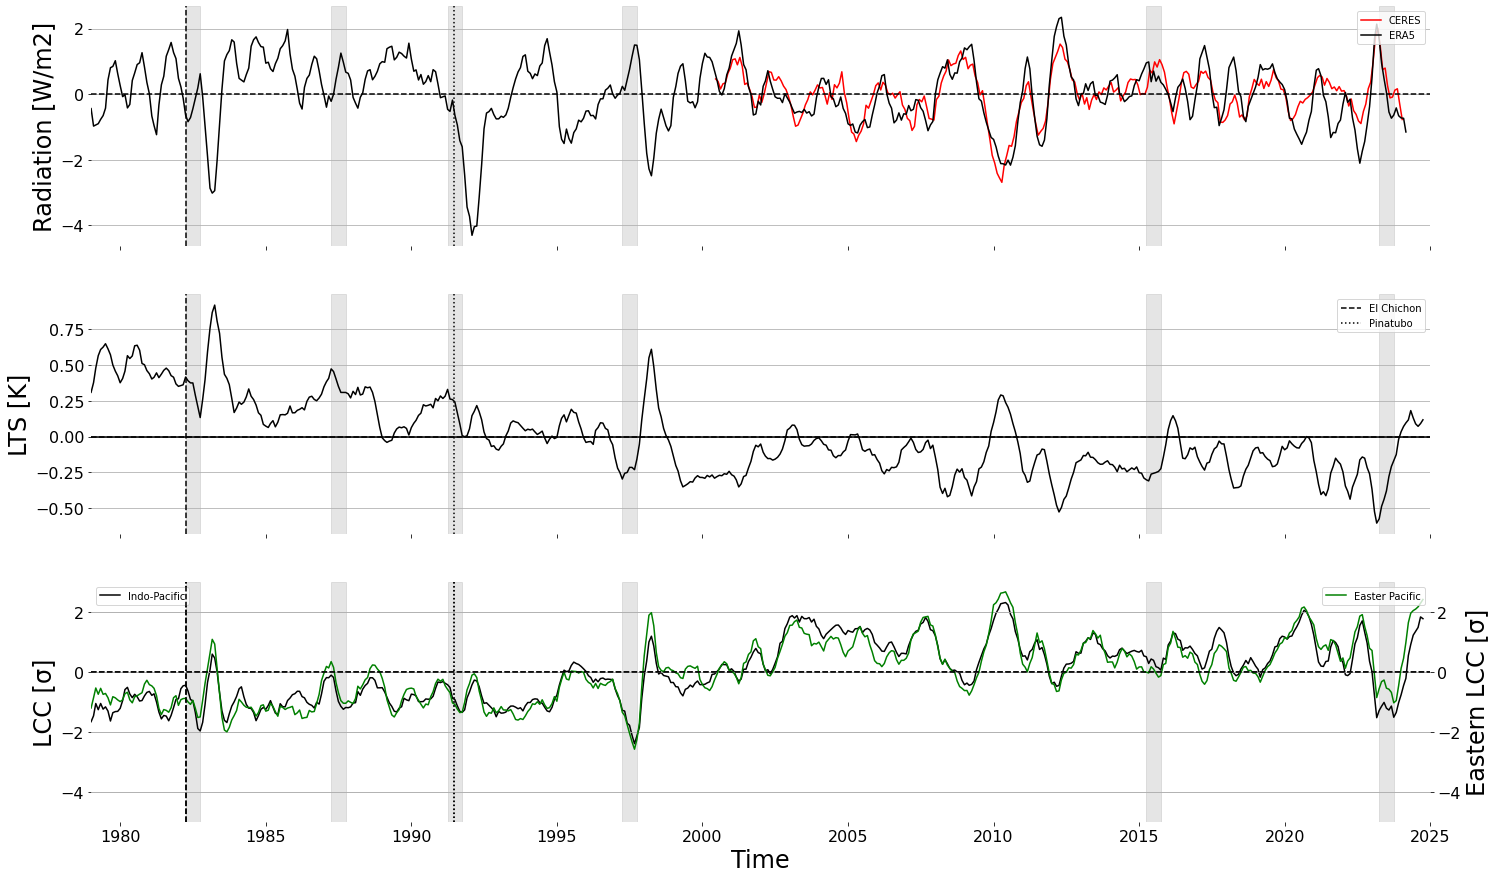

In [289]:
fig, axes = plt.subplots(3,1, figsize = (24,15), sharex = True)


#Radiation
axes[0].plot(r_anom.time, r_anom.detrended, c = 'r', label = 'CERES')
axes[0].plot(n_anom.time, n_anom.detrended, c = 'k', label = 'ERA5')
axes[0].set_ylabel('Radiation [W/m2]', fontsize = 24)
axes[0].legend(loc = 'upper right')

#LTS
axes[1].plot(LTS_anom.time, LTS_anom.detrended, c = 'k')
axes[1].set_ylabel('LTS [K]', fontsize = 24)
#axes[0].axhline(0, c = 'k', linestyle = '-')



#Low Cloud Cover
axes[2].plot(clouds_anom.time, clouds_anom.detrended/clouds_anom.detrended.std(),
             c = 'k', label = 'Indo-Pacific')
axes[1].axhline(0, linestyle = '-', c = 'k')
#axes[2].axhline(3, linestyle = 'dotted', c = 'grey')
#axes[2].axhline(-3, linestyle = 'dotted', c = 'grey')

axes[2].set_ylim(-5,3)

axes[2].set_ylabel('LCC [σ]', fontsize = 24)
axes[2].set_xlabel('Time', fontsize = 24)
axes[2].legend(loc = 'upper left')


#Eastern Low cloud
axeast = axes[2].twinx()
axeast.plot(eclouds_anom.time, eclouds_anom.detrended/eclouds_anom.detrended.std(),
            c = 'green', label = 'Easter Pacific')
axeast.legend(loc = 'upper right')


axeast.set_ylim(-5,3)

axeast.set_ylabel('Eastern LCC [σ]', fontsize = 24)

axes[2].tick_params(axis='x', labelsize = 16)

# Fill the regions for the specified years
for year in composite_years+['2023']:
    start = np.datetime64(f"{year}-04-01")
    end = np.datetime64(f"{year}-09-30")
    for ax in axes:
        ax.axvspan(start, end, color='gray', alpha=0.2)
    
    
for ax in [*axes, axeast]:
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.tick_params(axis='y', labelsize = 16)
    
    ax.spines[:].set_visible(False)
    ax.grid(axis = 'y')
    ax.set_xlim(np.datetime64('1979'), np.datetime64('2025'))
    
    #add colcanic eruption times
    ax.axvline(np.datetime64('1982-04-01'), label = 'El Chichon', c = 'k', linestyle = '--')
    ax.axvline(np.datetime64('1991-06-15'), label = 'Pinatubo', c = 'k', linestyle = ':')
    
axes[1].legend(loc = 'upper right')
